In [3]:
import numpy as np
import torch
from skimage import io, transform
from segment_anything import sam_model_registry
import matplotlib.pyplot as plt
import os
import SimpleITK as sitk
import glob


from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import transforms, datasets
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics, ToUnknown, fix_random_seed

from torch.utils.data import Dataset
import torchvision.transforms.functional as TF

In [14]:
device = "cuda:1"
ckpt = "../work_dir/MedSAM/sam_vit_b_01ec64.pth"  
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

In [6]:
fix_random_seed(123)

datasets_path="../../datasets/"
prep_datasets="/prep_datasets"
ID_path= datasets_path + prep_datasets + "/ACDC_MR_Cardiac/not_RV_class/imgs" 


 # setup ID test data
id_dataset = NpyFolderDataset(ID_path, limit=1000, label=0)
id_loader  = DataLoader(id_dataset, batch_size=4, shuffle=False, num_workers=0)

In [7]:
OOD_path=datasets_path + prep_datasets + "/ACDC_MR_Cardiac/RV_class/imgs"
ood_dataset= NpyFolderDataset(OOD_path, limit=1000, label=0)
ood_dataset = LabelAsUnknown(ood_dataset, unknown_label=-1)
ood_loader = DataLoader(ood_dataset, batch_size=4, shuffle=False, num_workers=0)

In [8]:
print(len(ood_dataset))  # should be 20

750


In [9]:
imgs, labels = next(iter(id_loader))
imgs_ood,labels_ood=next(iter(ood_loader))
print(imgs.shape)

torch.Size([4, 3, 1024, 1024])


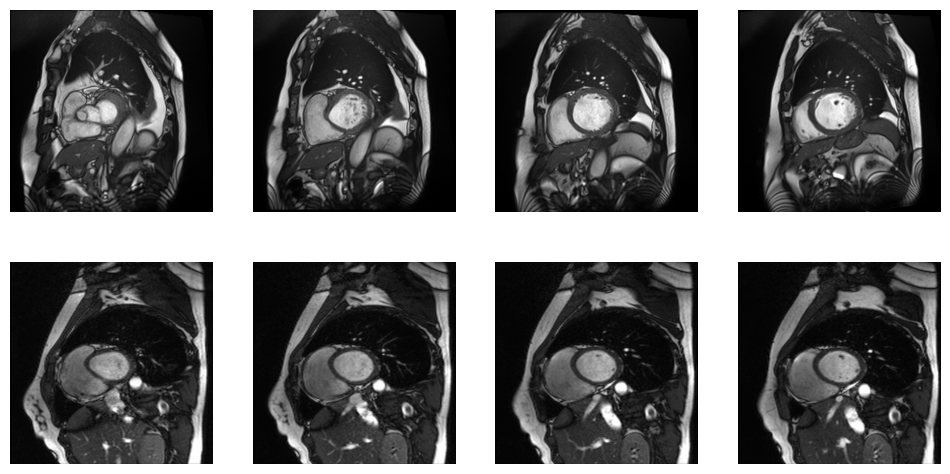

In [10]:
import matplotlib.pyplot as plt

imgs, labels = next(iter(id_loader))
imgs_ood, labels_ood = next(iter(ood_loader))

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i in range(4):
    # ID images (row 0)
    img = imgs[i].permute(1, 2, 0).cpu().numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis("off")

    # OOD images (row 1)
    img_ood = imgs_ood[i].permute(1, 2, 0).cpu().numpy()
    axes[1, i].imshow(img_ood)
    axes[1, i].axis("off")

plt.show()

In [15]:
# Stage 1: Create DNN
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

#Pass ID data through encoder and fit Mahalanobis distance metric

feats_list = []
labels_list = []

model.eval()

with torch.no_grad():
    for imgs, y in id_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        z = model.image_encoder(imgs)              # [B, C, H, W] (feature maps)
        z = z.mean(dim=(2, 3))                     # [B, C] global average pool

        feats_list.append(z)
        labels_list.append(y)

Z_id = torch.cat(feats_list, dim=0)               # [N, C]
Y_id = torch.cat(labels_list, dim=0)              # [N]



detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)

No device given. Will use 'cuda:1'.


In [17]:
#predict on OOD dataset


feats_list = []
with torch.no_grad():
    for imgs, _ in ood_loader:
        imgs = imgs.to(device)
        z = model.image_encoder(imgs)
        z = z.mean(dim=(2, 3))
        feats_list.append(z)

Z_ood = torch.cat(feats_list, dim=0)

scores_id  = detector.predict_features(Z_id)
scores_ood = detector.predict_features(Z_ood)

In [18]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(scores_id), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([scores_id.detach().cpu(), scores_ood.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.9999666810035706, 'AUTC': 0.3405618965625763, 'AUPR-IN': 0.9999752044677734, 'AUPR-OUT': 0.9999554753303528, 'FPR95TPR': 0.0}


In [4]:
class SaveAsNpy:
    def __init__(self, output_dir, subfolder="cifar10"):
        self.output_dir = Path(output_dir) / subfolder
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.counter = 0

    def __call__(self, img):
        np.save(self.output_dir / f"cifar10_{self.counter:05d}.npy",
                img.numpy())
        self.counter += 1
        return img
    
    


class NpyFolderDataset(Dataset):
    """
    Loads .npy files lazily from a folder. Returns (x, y).
    y can be a fixed label (e.g., 0 for ID), or you can extend to read labels.
    """
    def __init__(self, root, limit=None, transform=None, label=0):
        self.root = Path(root)
        self.transform = transform
        self.label = label

        self.files = sorted([p for p in self.root.iterdir() if p.suffix == ".npy"])
        if limit is not None:
            self.files = self.files[:int(limit)]

        if len(self.files) == 0:
            raise FileNotFoundError(f"No .npy files found in: {self.root}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        arr = np.load(path)  # numpy array
        x = torch.from_numpy(arr).float()

        # Ensure shape is [C,H,W]
        if x.ndim == 2:
            x = x.unsqueeze(0)  # [1,H,W]
        elif x.ndim == 3:
            # could be [H,W,C] or [C,H,W]
            if x.shape[-1] in (1, 3) and x.shape[0] not in (1, 3):
                x = x.permute(2, 0, 1)  # [C,H,W]

        if self.transform is not None:
            x = self.transform(x)

        return x, self.label
    
    

class LabelAsUnknown(Dataset):
    def __init__(self, base_dataset, unknown_label=-1):
        self.base = base_dataset
        self.unknown_label = unknown_label

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _y = self.base[idx]
        return x, self.unknown_label